In [84]:
import numpy as np
import random
import matplotlib.pyplot as plt

class WarehouseEnv:
    def __init__(self):
        self.h = 6
        self.w = 6
        self.shelves = {(1,2),(2,2),(3,2),(4,4)}
        self.pick_site = (0,5)
        self.drop_site = (5,0)
        self.actions = ['up','down','left','right','pick','drop']
        self.reset()

    def reset(self):
        self.pos = (0,0)
        self.carry = False
        return (self.pos,self.carry)

    def step(self, act):
        r = -1
        x,y = self.pos
        if act=='up':
            nx,ny=x-1,y
        elif act=='down':
            nx,ny=x+1,y
        elif act=='left':
            nx,ny=x,y-1
        elif act=='right':
            nx,ny=x,y+1
        else:
            nx,ny=x,y

        out = nx<0 or nx>=self.h or ny<0 or ny>=self.w
        block = (nx,ny) in self.shelves

        if act in ['up','down','left','right']:
            if out or block:
                r -= 20
            else:
                old = abs(x-self.drop_site[0]) + abs(y-self.drop_site[1])
                new = abs(nx-self.drop_site[0]) + abs(ny-self.drop_site[1])
                if new < old:
                    r += 0.4
                self.pos = (nx,ny)

        if act=='pick' and self.pos==self.pick_site and not self.carry:
            self.carry=True
            r+=25

        if act=='drop':
            if self.pos==self.drop_site and self.carry:
                r+=100
                return (self.pos,self.carry),r,True
            else:
                r-=5

        return (self.pos,self.carry),r,False

step: 0 state: ((0, 0), False) action: right reward: -1


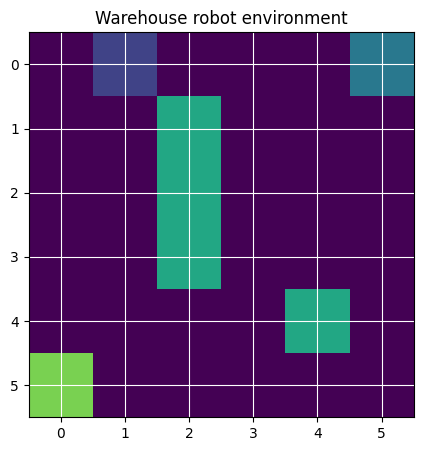

step: 1 state: ((0, 1), False) action: up reward: -21


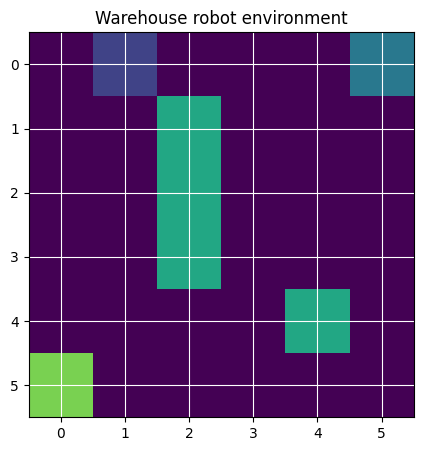

step: 2 state: ((0, 1), False) action: right reward: -1


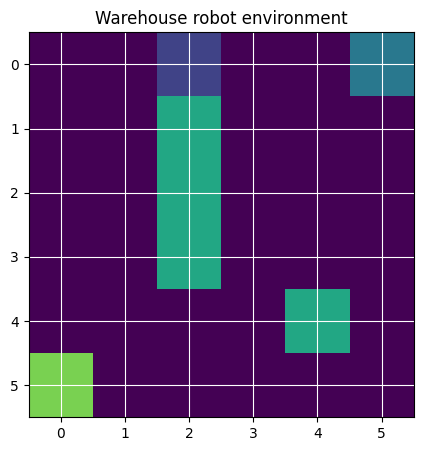

step: 3 state: ((0, 2), False) action: down reward: -21


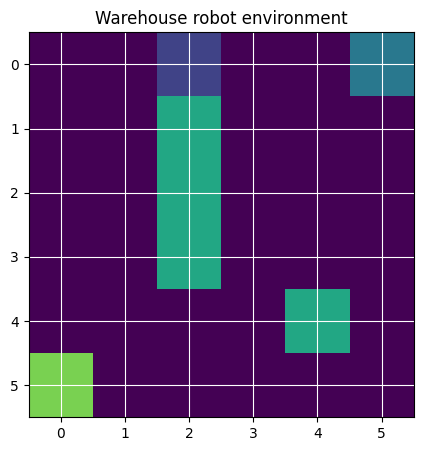

step: 4 state: ((0, 2), False) action: drop reward: -6


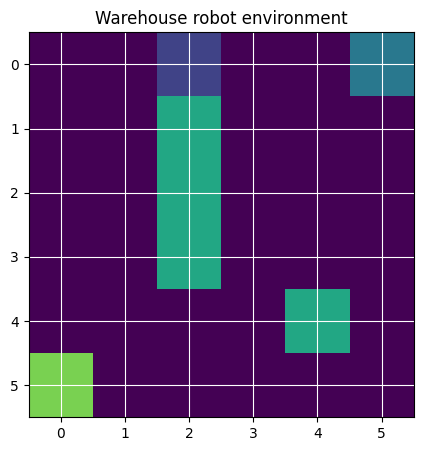

step: 5 state: ((0, 2), False) action: down reward: -21


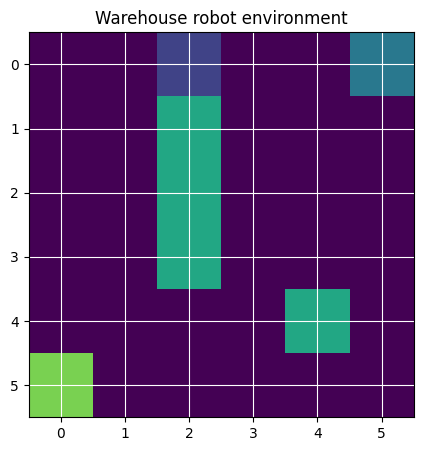

step: 6 state: ((0, 2), False) action: up reward: -21


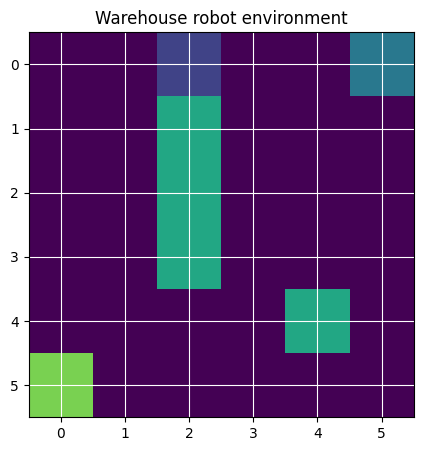

step: 7 state: ((0, 2), False) action: left reward: -0.6


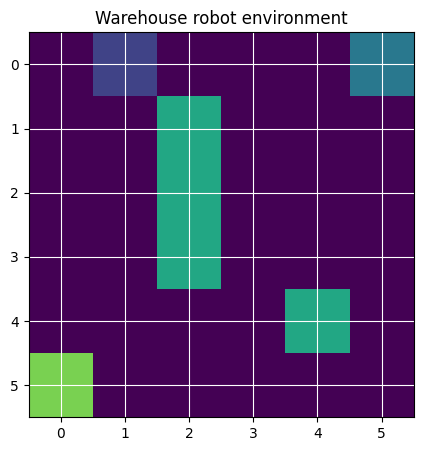

step: 8 state: ((0, 1), False) action: pick reward: -1


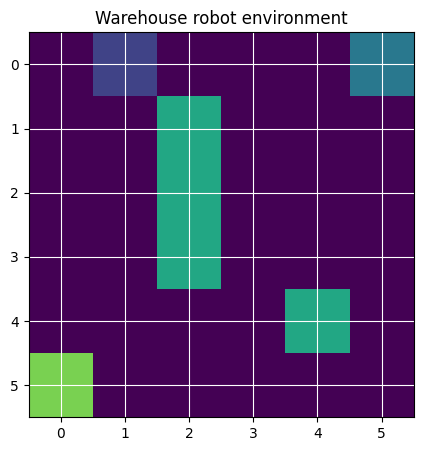

step: 9 state: ((0, 1), False) action: left reward: -0.6


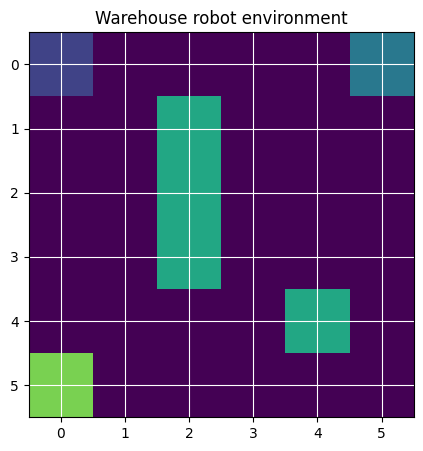

In [85]:
def draw(env):
    grid = np.zeros((env.h, env.w))
    for s in env.shelves:
        grid[s] = 3

    px,py = env.pick_site
    grid[px,py] = 2
    dx,dy = env.drop_site
    grid[dx,dy] = 4
    rx,ry = env.pos
    grid[rx,ry] = 1 if not env.carry else 5

    plt.figure(figsize=(5,5))
    plt.imshow(grid, cmap='viridis', vmin=0, vmax=5)
    plt.xticks(np.arange(env.w))
    plt.yticks(np.arange(env.h))
    plt.grid(True, color='white', linewidth=0.8)
    plt.title("Warehouse robot environment")
    plt.show()

env = WarehouseEnv()
state = env.reset()

for i in range(10):
    a = random.choice(env.actions)
    ns,r,d = env.step(a)
    print("step:",i,"state:",state,"action:",a,"reward:",r)
    draw(env)
    state = ns
    if d:
        break


In [86]:
Q = {}
for x in range(6):
    for y in range(6):
        for c in [True,False]:
            Q[((x,y),c)] = {a:0.0 for a in ['up','down','left','right','pick','drop']}

In [87]:
klist=list(Q.items())
for i in range(5):
    print(klist[i])

(((0, 0), True), {'up': 0.0, 'down': 0.0, 'left': 0.0, 'right': 0.0, 'pick': 0.0, 'drop': 0.0})
(((0, 0), False), {'up': 0.0, 'down': 0.0, 'left': 0.0, 'right': 0.0, 'pick': 0.0, 'drop': 0.0})
(((0, 1), True), {'up': 0.0, 'down': 0.0, 'left': 0.0, 'right': 0.0, 'pick': 0.0, 'drop': 0.0})
(((0, 1), False), {'up': 0.0, 'down': 0.0, 'left': 0.0, 'right': 0.0, 'pick': 0.0, 'drop': 0.0})
(((0, 2), True), {'up': 0.0, 'down': 0.0, 'left': 0.0, 'right': 0.0, 'pick': 0.0, 'drop': 0.0})


In [88]:
def choose(s,eps):
    if random.random() < eps:
        return random.choice(['up','down','left','right','pick','drop'])
    return max(Q[s], key=Q[s].get)

In [89]:
env = WarehouseEnv()
episodes = 4000
alpha = 0.15
gamma = 0.9
eps = 1.0
eps_min = 0.05
eps_decay = 0.9993

rew_hist = []
eps_track = []
for i in range(episodes):
    s = env.reset()
    a = choose(s,eps)
    total = 0
    done = False
    t = 0

    while not done and t < 400:
        ns,r,done = env.step(a)
        na = choose(ns,eps)
        td = r + gamma * Q[ns][na] - Q[s][a]
        Q[s][a] += alpha * td
        s,a = ns,na
        total += r
        t += 1

    rew_hist.append(total)
    eps_track.append(eps)
    eps = max(eps_min, eps * eps_decay)

In [90]:
klist=list(Q.items())
for i in range(5):
    print(klist[i])

(((0, 0), True), {'up': -50.789418638697455, 'down': -25.097402395603332, 'left': -55.82168202594122, 'right': -32.22209745799161, 'pick': -36.39661502198307, 'drop': -37.65908456874775})
(((0, 0), False), {'up': 10.962783447868045, 'down': 43.68145609597688, 'left': 11.79940252430425, 'right': 26.431141683593253, 'pick': 25.2900432632673, 'drop': 22.22695375206215})
(((0, 1), True), {'up': -53.09958004219748, 'down': -20.93771022439693, 'left': -34.22223458136966, 'right': -36.64624096101063, 'pick': -39.22341169518886, 'drop': -38.10059865198157})
(((0, 1), False), {'up': -31.697963228791878, 'down': 38.81416194358814, 'left': -7.659737563823871, 'right': -22.39218130403983, 'pick': -22.14835243743039, 'drop': -22.295404533638404})
(((0, 2), True), {'up': -60.05263201856561, 'down': -56.99194412549703, 'left': -26.41975977066146, 'right': -38.5901157566215, 'pick': -34.96305032777948, 'drop': -41.14754874354207})


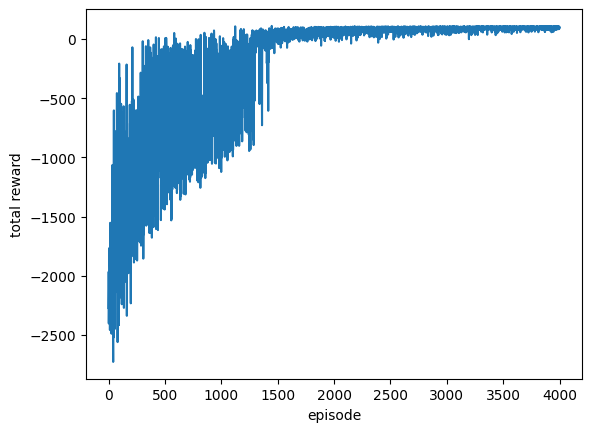

In [91]:
plt.plot(rew_hist)
plt.xlabel("episode")
plt.ylabel("total reward")
plt.show()

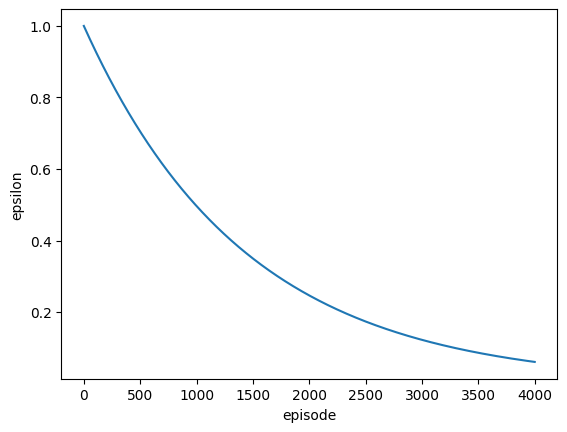

In [92]:
plt.plot(eps_track)
plt.xlabel("episode")
plt.ylabel("epsilon")
plt.show()

In [93]:
eval_rewards = []
for i in range(10):
    s = env.reset()
    total = 0
    done = False
    t = 0
    while not done and t < 200:
        a = max(Q[s],key=Q[s].get)
        ns,r,done = env.step(a)
        total += r
        s = ns
        t += 1
    eval_rewards.append(total)

eval_rewards

[105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001,
 105.60000000000001]

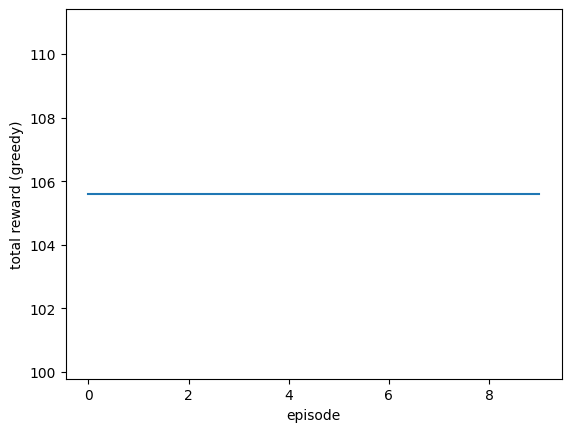

In [94]:
plt.plot(eval_rewards)
plt.xlabel("episode")
plt.ylabel("total reward (greedy)")
plt.show()

References: Grid world - https://codesignal.com/learn/courses/environment-engineering-foundation-of-rl-systems/lessons/building-a-grid-world-environment-for-reinforcement-learning

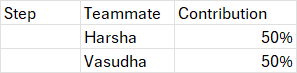